# 02 — Environment Rollout Diagnostics (Plots)

Goal: run controlled rollouts and plot:
- SoC trajectory (bounds + dynamics)
- P_req vs P_applied (clipping visibility)
- planned vs applied power
- DA vs ID prices
- DA availability step function
- reward decomposition (profit_norm vs carbon_penalty_norm)

# 0. Imports + Env Factory

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from battery_env import BatteryEnv
import env_config

pd.set_option("display.max_columns", 200)

def make_env(seed=123, publish_hour=12, episode_days=5, randomize_init_soc=True):
    env = BatteryEnv(
        config=env_config,
        publish_hour=publish_hour,
        episode_days=episode_days,
        randomize_init_soc=randomize_init_soc,
        seed=seed,
    )
    return env

env = make_env(seed=123, episode_days=5, randomize_init_soc=True)
obs, info = env.reset(seed=123)
print("obs_len:", len(obs), "info:", info)

ID Scale: 32.7871178125
DA Scale: 33.393919999999994
Carbon Scale: 25.52995
obs_len: 103 info: {'start_day': '2022-03-06T00:00:00.000000000', 'publish_hour': 12, 'episode_days': 5, 'init_soc': 0.5729407452992573}


## 1. Rollout runner → DataFrame

In [2]:
def run_rollout(env, n_steps, policy_fn, seed=123):
    obs, info0 = env.reset(seed=seed)
    rows = []
    for t in range(n_steps):
        action = policy_fn(env, obs, t)
        obs, rew, terminated, truncated, info = env.step(action)
        done = bool(terminated or truncated)

        row = {"t": t, "reward": float(rew), "done": done}
        for k, v in info.items():
            row[k] = v
        rows.append(row)

        if done:
            break

    df = pd.DataFrame(rows)
    # ensure timestamps are parsed for plotting convenience
    for col in ["delivery_ts", "decision_ts"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])
    return df

## 2. Policies

In [3]:
def policy_random(env, obs, t, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    a = env.action_space.sample()
    return np.array(a, dtype=np.int64)

def policy_do_nothing(env, obs, t):
    mid = env.n_power_levels // 2
    return np.array([mid, mid, 0], dtype=np.int64)

def policy_force_extremes(env, obs, t):
    # alternate charge/discharge to trigger clipping and SoC movement
    charge_idx = 0
    discharge_idx = env.n_power_levels - 1
    plan_idx = env.n_power_levels // 2
    plan_slot = (t % 48)
    dispatch = charge_idx if (t % 2 == 0) else discharge_idx
    return np.array([dispatch, plan_idx, plan_slot], dtype=np.int64)

## 3. Run 3 Rollouts

In [4]:
rng = np.random.default_rng(123)

df_rand = run_rollout(env, n_steps=300, policy_fn=lambda e,o,t: policy_random(e,o,t,rng=rng), seed=123)
df_zero = run_rollout(env, n_steps=300, policy_fn=policy_do_nothing, seed=123)
df_ext  = run_rollout(env, n_steps=300, policy_fn=policy_force_extremes, seed=123)

print("rand steps:", len(df_rand), "zero steps:", len(df_zero), "ext steps:", len(df_ext))
df_rand.head()

rand steps: 240 zero steps: 240 ext steps: 240


,t,reward,done,trade_date,delivery_date,tau,decision_ts,delivery_ts,trade_ts,dispatch_idx_exec,dispatch_idx_agent,plan_idx_agent,planned_idx_today,plan_slot_agent,tomorrow_plan_value_written,P_req_MW,P_planned_MW,P_dev_MW,P_applied_MW,delta_soc,id_price_now,da_price_now,ci_now,Planned_Profit,Intraday_Profit,profit_norm,carbon_penalty_norm,da_available,days_done,soc
0,0,-0.682186,False,2022-03-05 00:00:00,2022-03-06 00:00:00,1,2022-03-06 00:00:00,2022-03-06 00:00:00,2022-03-05 00:00:00,2,2,0,-1,45,-999,-0.11181,0.0,-0.111810,-0.111810,0.142694,274.769989,320.000000,127.0,0.0,-0.436993,-0.436993,0.245193,False,0,0.715635
1,1,-0.904116,False,2022-03-05 00:00:00,2022-03-06 00:00:00,2,2022-03-06 00:30:00,2022-03-06 00:30:00,2022-03-05 00:30:00,0,0,9,-1,18,-999,-0.18635,0.0,-0.146233,-0.146233,0.184365,299.329987,361.000000,129.0,0.0,-0.583345,-0.583345,0.320770,False,0,0.900000
2,2,0.000000,False,2022-03-05 00:00:00,2022-03-06 00:00:00,3,2022-03-06 01:00:00,2022-03-06 01:00:00,2022-03-05 01:00:00,5,5,6,-1,38,-999,0.00000,0.0,0.000000,0.000000,0.000000,298.790009,355.200012,130.0,0.0,0.000000,0.000000,-0.000000,False,0,0.900000
3,3,0.000000,False,2022-03-05 00:00:00,2022-03-06 00:00:00,4,2022-03-06 01:30:00,2022-03-06 01:30:00,2022-03-05 01:30:00,2,2,5,-1,32,-999,-0.11181,0.0,0.000000,0.000000,0.000000,288.929993,330.000000,131.0,0.0,0.000000,0.000000,-0.000000,False,0,0.900000
4,4,0.000000,False,2022-03-05 00:00:00,2022-03-06 00:00:00,5,2022-03-06 02:00:00,2022-03-06 02:00:00,2022-03-05 02:00:00,3,3,9,-1,4,-999,-0.07454,0.0,0.000000,0.000000,0.000000,279.709991,330.000000,131.0,0.0,0.000000,0.000000,-0.000000,False,0,0.900000


## 4. Helper: clipping indicator + basic metrics

In [20]:
def add_clipping_flags(df):
    df = df.copy()
    if "P_req_MW" in df.columns and "P_applied_MW" in df.columns:
        df["clipped"] = np.abs(df["P_req_MW"] - df["P_applied_MW"]) > 1e-6
    else:
        df["clipped"] = False
    return df

def metrics(df):
    out = {}
    if "soc" in df.columns:
        out["soc_min"] = float(np.min(df["soc"]))
        out["soc_max"] = float(np.max(df["soc"]))
    if "clipped" in df.columns:
        out["clip_rate"] = float(np.mean(df["clipped"]))
    out["mean_reward"] = float(np.mean(df["reward"])) if len(df) else np.nan
    return out

df_rand = add_clipping_flags(df_rand)
df_zero = add_clipping_flags(df_zero)
df_ext  = add_clipping_flags(df_ext)

print("Random:", metrics(df_rand))
print("Do-nothing:", metrics(df_zero))
print("Extremes:", metrics(df_ext))

Random: {'soc_min': 0.19999999999999918, 'soc_max': 0.9000000000000007, 'clip_rate': 0.2833333333333333, 'mean_reward': 0.004849405932868208}
Do-nothing: {'soc_min': 0.5729407452992573, 'soc_max': 0.5729407452992573, 'clip_rate': 0.0, 'mean_reward': 0.0}
Extremes: {'soc_min': 0.19999999999999937, 'soc_max': 0.8092611446495056, 'clip_rate': 0.3125, 'mean_reward': -0.008329410934767533}


## 5. Plot 1: SoC over time

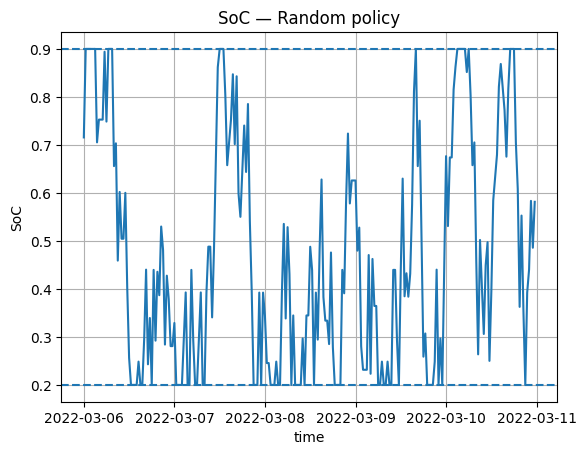

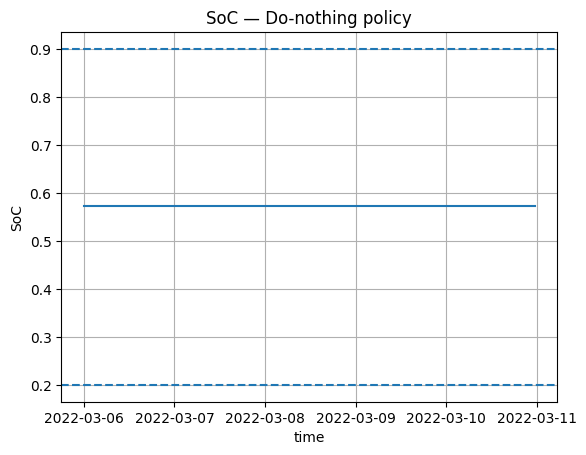

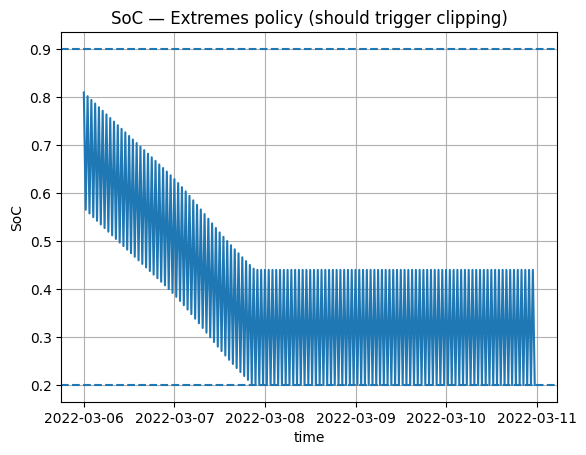

In [21]:
def plot_soc(df, title):
    plt.figure()
    if "delivery_ts" in df.columns:
        x = df["delivery_ts"]
    else:
        x = df["t"]
    plt.plot(x, df["soc"])
    plt.axhline(env.SoC_min, linestyle="--")
    plt.axhline(env.SoC_max, linestyle="--")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("SoC")
    plt.grid(True)
    plt.show()

plot_soc(df_rand, "SoC — Random policy")
plot_soc(df_zero, "SoC — Do-nothing policy")
plot_soc(df_ext,  "SoC — Extremes policy (should trigger clipping)")

## 6. Plot 2: Power request vs applied (clipping visibility)

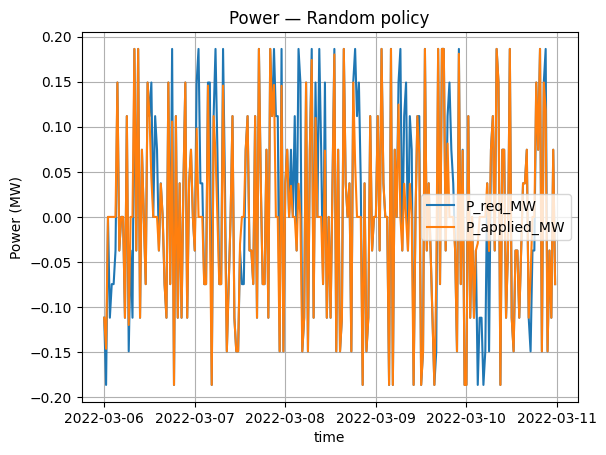

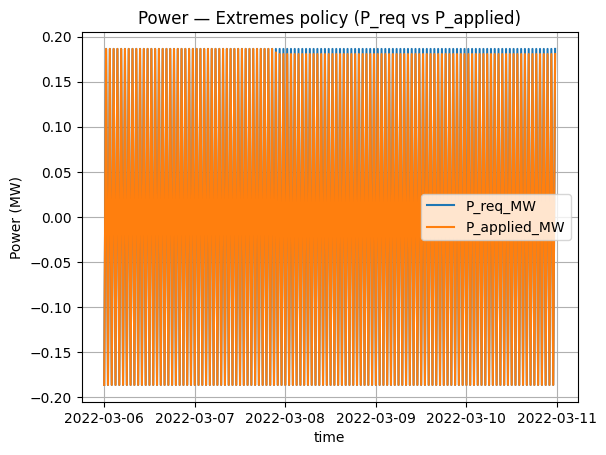

In [22]:
def plot_power_req_vs_applied(df, title):
    plt.figure()
    x = df["delivery_ts"] if "delivery_ts" in df.columns else df["t"]
    if "P_req_MW" in df.columns:
        plt.plot(x, df["P_req_MW"], label="P_req_MW")
    if "P_applied_MW" in df.columns:
        plt.plot(x, df["P_applied_MW"], label="P_applied_MW")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("Power (MW)")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_power_req_vs_applied(df_rand, "Power — Random policy")
plot_power_req_vs_applied(df_ext,  "Power — Extremes policy (P_req vs P_applied)")

## 7. Plot 3: Planned vs applied power

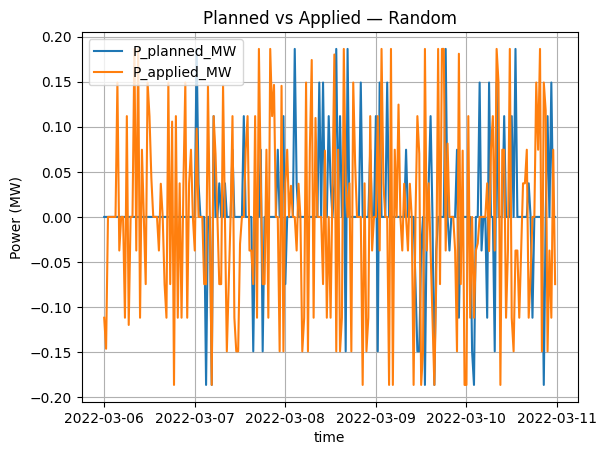

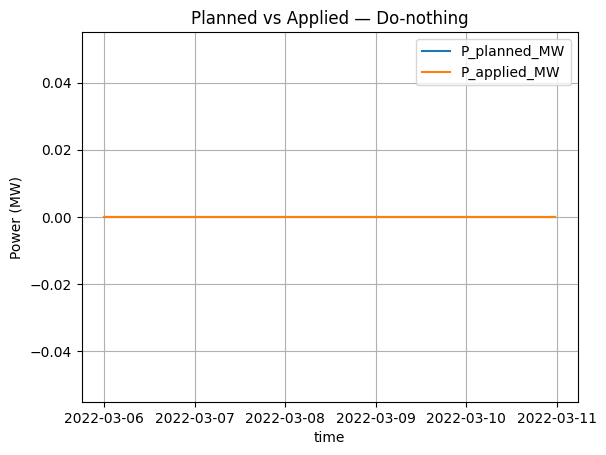

,delivery_ts,tau,P_planned_MW,P_applied_MW,P_dev_MW,soc,Planned_Profit,Intraday_Profit,da_available,reward
0,2022-03-06 00:00:00,1,0.0,-0.111810,-0.111810,0.715635,0.0,-0.436993,False,-0.682186
1,2022-03-06 00:30:00,2,0.0,-0.146233,-0.146233,0.900000,0.0,-0.583345,False,-0.904116
2,2022-03-06 01:00:00,3,0.0,0.000000,0.000000,0.900000,0.0,0.000000,False,0.000000
3,2022-03-06 01:30:00,4,0.0,0.000000,0.000000,0.900000,0.0,0.000000,False,0.000000
4,2022-03-06 02:00:00,5,0.0,0.000000,0.000000,0.900000,0.0,0.000000,False,0.000000
5,2022-03-06 02:30:00,6,0.0,0.000000,0.000000,0.900000,0.0,0.000000,False,0.000000
6,2022-03-06 03:00:00,7,0.0,0.000000,0.000000,0.900000,0.0,0.000000,False,0.000000
7,2022-03-06 03:30:00,8,0.0,0.149080,0.149080,0.705336,0.0,0.573033,False,0.908955
8,2022-03-06 04:00:00,9,0.0,-0.037270,-0.037270,0.752760,0.0,-0.160958,False,-0.246805
9,2022-03-06 04:30:00,10,0.0,0.000000,0.000000,0.752760,0.0,0.000000,False,0.000000


In [ ]:
def plot_planned_vs_applied(df, title):
    plt.figure()
    x = df["delivery_ts"] if "delivery_ts" in df.columns else df["t"]
    if "P_planned_MW" in df.columns:
        plt.plot(x, df["P_planned_MW"], label="P_planned_MW")
    if "P_applied_MW" in df.columns:
        plt.plot(x, df["P_applied_MW"], label="P_applied_MW")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("Power (MW)")
    plt.grid(True)
    plt.legend()
    plt.show()

def planned_vs_applied_table(df, n):
    cols = [
        "delivery_ts",
        "tau",
        "P_planned_MW",
        "P_applied_MW",
        "P_dev_MW",
        "soc",
        "Planned_Profit",
        "Intraday_Profit",
        "carbon_penalty_norm",
        "da_available",
        "reward",
    ]
    cols = [c for c in cols if c in df.columns]
    return df[cols].head(n)



plot_planned_vs_applied(df_rand, "Planned vs Applied — Random")
plot_planned_vs_applied(df_zero, "Planned vs Applied — Do-nothing")
planned_vs_applied_table(df_rand, n=25)

## 8.Plot 4: Prices (DA vs ID) + carbon intensity

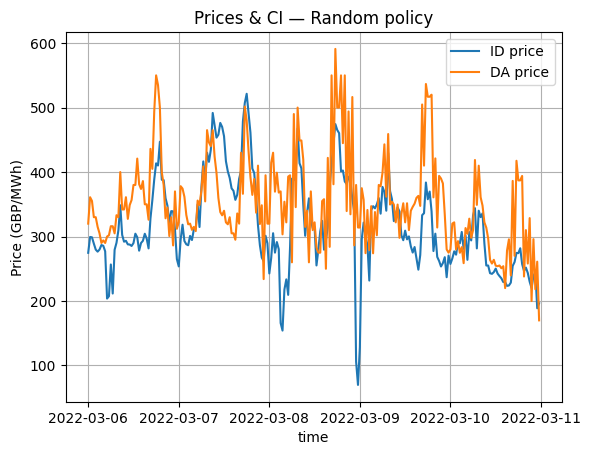

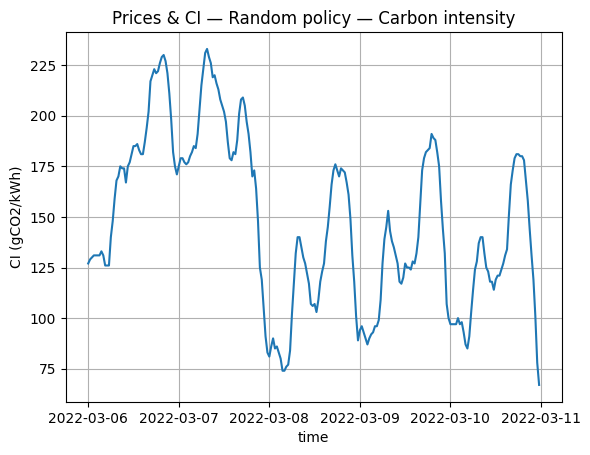

In [24]:
def plot_prices_and_ci(df, title):
    plt.figure()
    x = df["delivery_ts"] if "delivery_ts" in df.columns else df["t"]
    if "id_price_now" in df.columns:
        plt.plot(x, df["id_price_now"], label="ID price")
    if "da_price_now" in df.columns:
        plt.plot(x, df["da_price_now"], label="DA price")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("Price (GBP/MWh)")
    plt.grid(True)
    plt.legend()
    plt.show()

    if "ci_now" in df.columns:
        plt.figure()
        plt.plot(x, df["ci_now"])
        plt.title(title + " — Carbon intensity")
        plt.xlabel("time")
        plt.ylabel("CI (gCO2/kWh)")
        plt.grid(True)
        plt.show()

plot_prices_and_ci(df_rand, "Prices & CI — Random policy")

## 9.  Plot 5: DA availability indicator

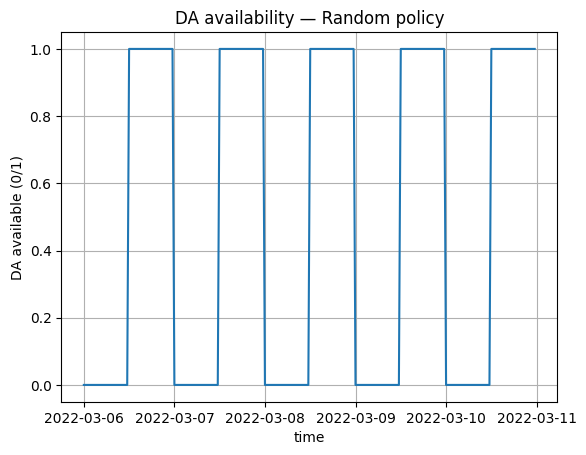

In [25]:
def plot_da_availability(df, title):
    if "da_available" not in df.columns:
        print("da_available not in df")
        return
    plt.figure()
    x = df["delivery_ts"] if "delivery_ts" in df.columns else df["t"]
    plt.plot(x, df["da_available"].astype(int))
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("DA available (0/1)")
    plt.grid(True)
    plt.show()

plot_da_availability(df_rand, "DA availability — Random policy")

## 10. Plot 6: Reward decomposition (profit_norm vs carbon_penalty_norm vs reward)

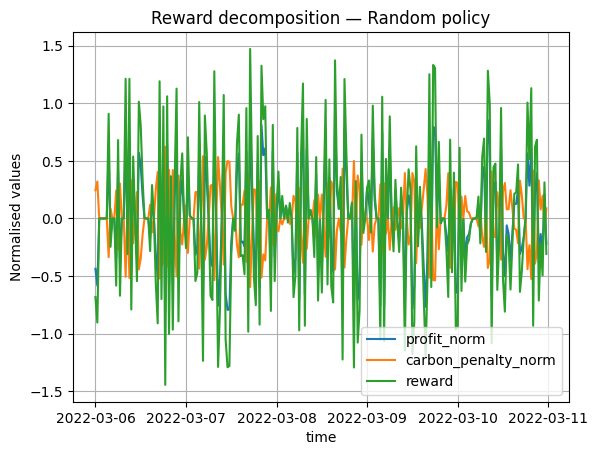

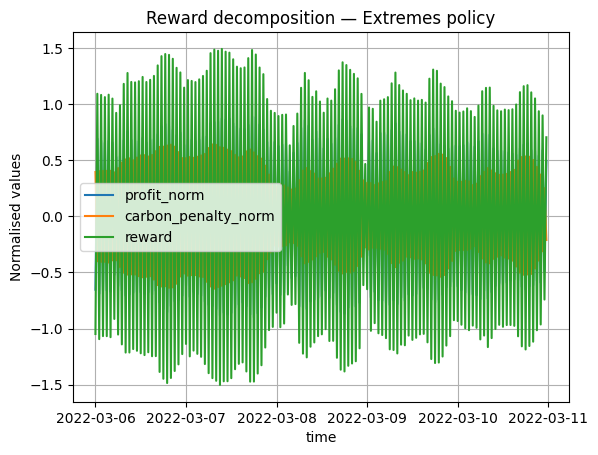

In [26]:
def plot_reward_decomposition(df, title):
    plt.figure()
    x = df["delivery_ts"] if "delivery_ts" in df.columns else df["t"]
    if "profit_norm" in df.columns:
        plt.plot(x, df["profit_norm"], label="profit_norm")
    if "carbon_penalty_norm" in df.columns:
        plt.plot(x, df["carbon_penalty_norm"], label="carbon_penalty_norm")
    plt.plot(x, df["reward"], label="reward")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("Normalised values")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_reward_decomposition(df_rand, "Reward decomposition — Random policy")
plot_reward_decomposition(df_ext,  "Reward decomposition — Extremes policy")

## 11. Plot 7: clipping histogram + applied power distribution

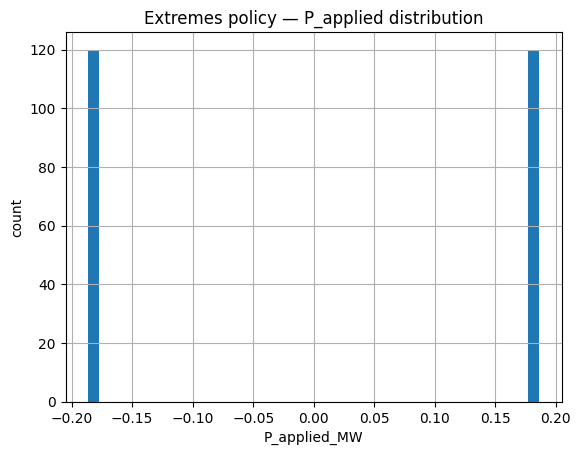

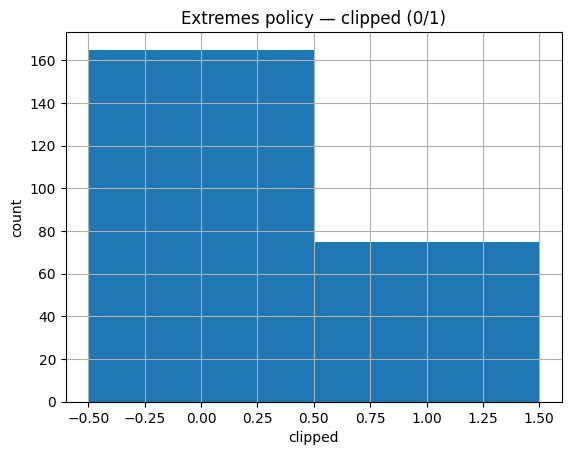

In [27]:
def plot_distributions(df, title):
    plt.figure()
    if "P_applied_MW" in df.columns:
        plt.hist(df["P_applied_MW"].dropna().to_numpy(), bins=40)
        plt.title(title + " — P_applied distribution")
        plt.xlabel("P_applied_MW")
        plt.ylabel("count")
        plt.grid(True)
        plt.show()

    if "clipped" in df.columns:
        plt.figure()
        plt.hist(df["clipped"].astype(int).to_numpy(), bins=[-0.5,0.5,1.5])
        plt.title(title + " — clipped (0/1)")
        plt.xlabel("clipped")
        plt.ylabel("count")
        plt.grid(True)
        plt.show()

plot_distributions(df_ext, "Extremes policy")

# Summary

In [28]:
summary = pd.DataFrame([
    {"policy": "random", **metrics(df_rand)},
    {"policy": "do_nothing", **metrics(df_zero)},
    {"policy": "extremes", **metrics(df_ext)},
])
summary

,policy,soc_min,soc_max,clip_rate,mean_reward
0,random,0.200000,0.900000,0.283333,0.004849
1,do_nothing,0.572941,0.572941,0.000000,0.000000
2,extremes,0.200000,0.809261,0.312500,-0.008329
